<a href="https://colab.research.google.com/github/luladc/IA2/blob/main/examen3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                     Turbidez  Solidos  Color  Calidad_Global_ICA
2025-01-01 00:00:00      1.46    270.1    6.5               73.56
2025-01-01 08:00:00      1.57    374.8    4.7               69.82
2025-01-01 16:00:00      0.57    454.7    4.9               71.54
2025-01-02 00:00:00      2.06    287.0    4.5               71.19
2025-01-02 08:00:00      1.81    366.4    4.9               70.91
2025-01-02 16:00:00      2.17    325.5    6.7               58.93
2025-01-03 00:00:00      0.26    381.6    2.8               70.14
2025-01-03 08:00:00      2.78    363.0    6.6               54.53
2025-01-03 16:00:00      1.70    331.7    5.7               68.01
2025-01-04 00:00:00      2.36    389.8    4.3               66.71


IndexError: index 4 is out of bounds for axis 0 with size 4

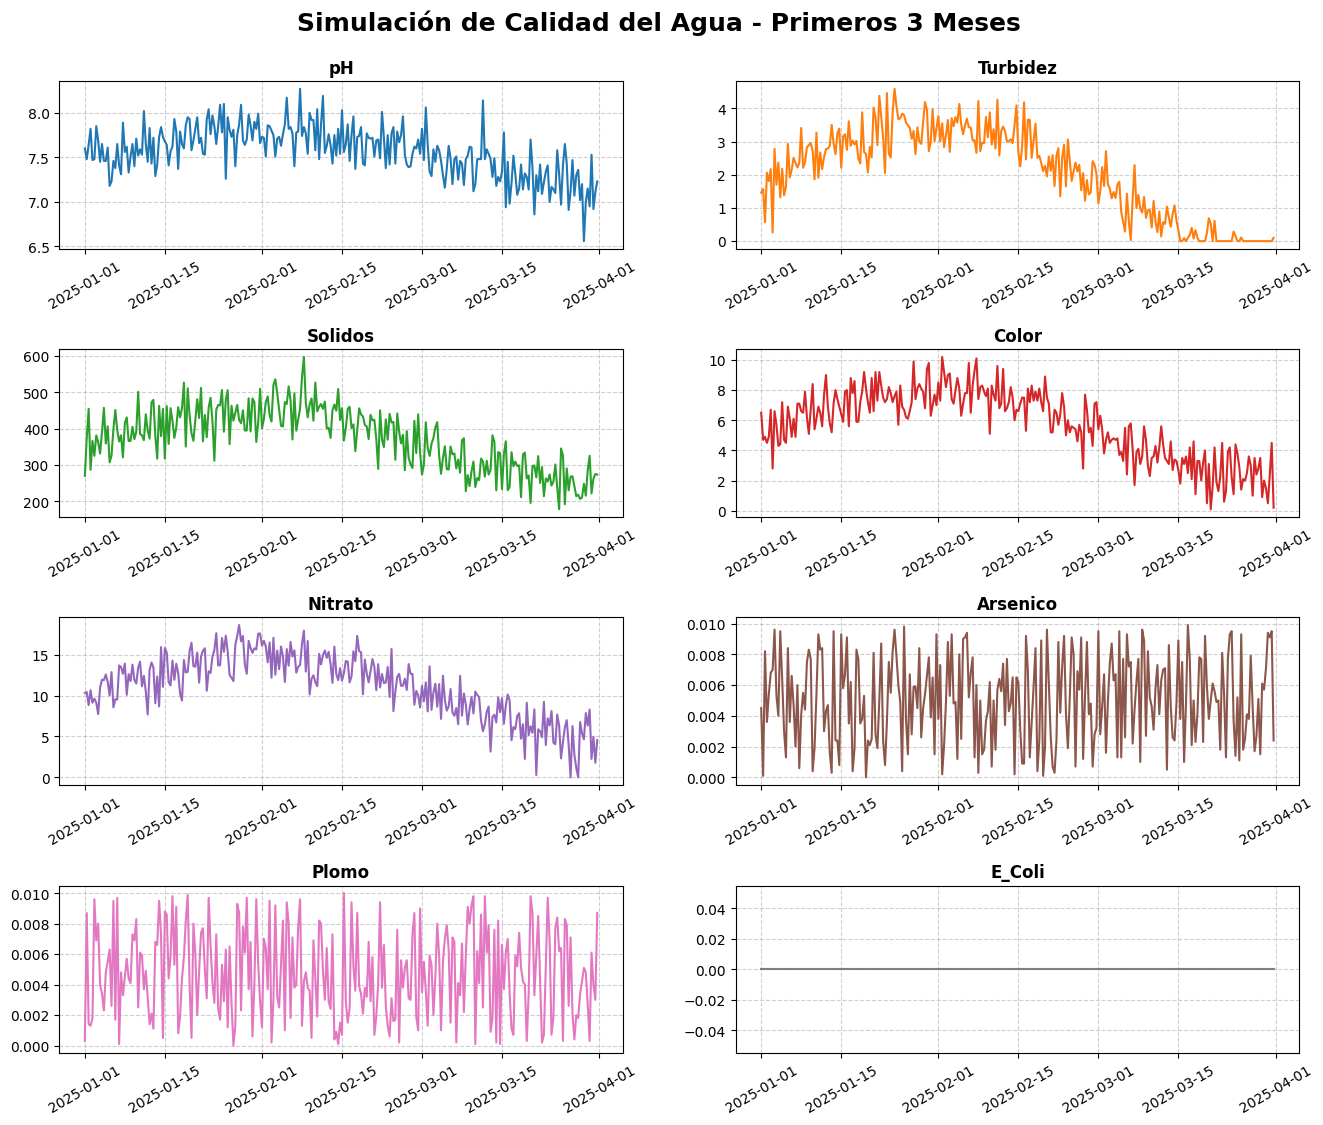

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
#tiempo de un año y se toma muestras 3 veces al dia, mañana tarde y noche
fechas = pd.date_range(start='2025-01-01', periods=365*3, freq='8h')
n_muestras = len(fechas)

#esto simula lluvias
tiempo = np.arange(n_muestras)
onda_climatica = np.sin(tiempo / (n_muestras / (3 * 2 * np.pi)))

# Generamos los datos basándonos en la onda climática para darles una tendencia
ph = np.clip(7.5 + onda_climatica * 0.3 + np.random.normal(0, 0.2, n_muestras), 6.5, 9.0)
turbidez = np.clip(1.5 + onda_climatica * 2 + np.random.normal(0, 0.5, n_muestras), 0, 5)
solidos = np.clip(350 + onda_climatica * 100 + np.random.normal(0, 50, n_muestras), 0, 1000)
color = np.clip(5 + onda_climatica * 3 + np.random.normal(0, 1, n_muestras), 0, 15)
nitrato = np.clip(10 + onda_climatica * 5 + np.random.normal(0, 2, n_muestras), 0, 45)
arsenico = np.random.uniform(0.0, 0.01, n_muestras)
plomo = np.random.uniform(0.0, 0.01, n_muestras)
coli = np.zeros(n_muestras, dtype=int)

df_agua = pd.DataFrame({
    'pH': np.round(ph, 2),
    'Turbidez': np.round(turbidez, 2),
    'Solidos': np.round(solidos, 1),
    'Color': np.round(color, 1),
    'Nitrato': np.round(nitrato, 2),
    'Arsenico': np.round(arsenico, 4),
    'Plomo': np.round(plomo, 4),
    'E_Coli': coli
}, index=fechas)

def calcular_calidad(row):
    calidad = 100
    calidad -= (row['Turbidez'] / 5) * 20
    calidad -= (row['Solidos'] / 1000) * 15

    calidad -= (row['Color'] / 15) * 15

    calidad -= (row['Nitrato'] / 45) * 20

    desviacion_ph = abs(row['pH'] - 7.5)
    calidad -= (desviacion_ph / 1.5) * 10

    calidad -= (row['Arsenico'] / 0.01) * 10
    calidad -= (row['Plomo'] / 0.01) * 10

    return max(0, np.round(calidad, 2))

# APLICAMOS LA ECUACION A TODAS LAS FILAS
df_agua['Calidad_Global_ICA'] = df_agua.apply(calcular_calidad, axis=1)

print(df_agua[['Turbidez', 'Solidos', 'Color', 'Calidad_Global_ICA']].head(10))

df_agua.to_csv('dataset_calidad_integral.csv')

df_subset = df_agua.iloc[:270]

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
fig.suptitle('Simulación de Calidad del Agua - Primeros 3 Meses', fontsize=18, fontweight='bold')
fig.subplots_adjust(top=0.92, hspace=0.6, wspace=0.2)

color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, col in enumerate(df_agua.columns):
    ax = axes[i // 2, i % 2]
    ax.plot(df_subset.index, df_subset[col], color=color_palette[i], linewidth=1.5)
    ax.set_title(col, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=30)


plt.show()

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
import plotly.graph_objects as go
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import math

columna_objetivo = 'Calidad_Global_ICA'

# Escalado a [0, 1] para ayudar a la red a converger más rápido
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df_agua[[columna_objetivo]].values)

# Secuencias: Mirar 7 días (21 turnos) para predecir 1 turno hacia adelante
def create_sequences(data, seq_length, horizon):
    xs, ys = [], []
    for i in range(len(data) - seq_length - horizon + 1):
        xs.append(data[i:(i + seq_length)])
        ys.append(data[i + seq_length + horizon - 1])
    return np.array(xs), np.array(ys)

SEQ_LEN = 21
HORIZONTE = 1
X, y = create_sequences(data_scaled, SEQ_LEN, HORIZONTE)

# División Cronológica: 70% Entreno, 15% Validación, 15% Prueba
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32).reshape(-1, 1)
X_val = torch.tensor(X[train_size:train_size+val_size], dtype=torch.float32)
y_val = torch.tensor(y[train_size:train_size+val_size], dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X[train_size+val_size:], dtype=torch.float32)
y_test = torch.tensor(y[train_size+val_size:], dtype=torch.float32).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ModeloCalidadAgua(nn.Module):
    def __init__(self, model_type='LSTM', input_size=1, hidden_size=64, num_layers=2):
        super(ModeloCalidadAgua, self).__init__()

        if model_type == 'GRU':
            self.recurrent = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        else:
            self.recurrent = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.recurrent(x)
        if isinstance(out, tuple):
            out = out[0]
        out = out[:, -1, :]
        return self.fc(out)

def entrenar_modelo(model_type, epochs=60, patience=20):
    print(f"\n[{model_type}] Iniciando entrenamiento (Predicción de Calidad ICA)...")
    modelo = ModeloCalidadAgua(model_type=model_type).to(device)
    optimizer = torch.optim.Adam(modelo.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')
    early_stop_counter = 0
    best_model = None

    for epoch in range(epochs):
        modelo.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = modelo(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

        modelo.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = modelo(X_batch)
                val_loss += criterion(y_pred, y_batch).item()

        avg_val_loss = val_loss / len(val_loader)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{model_type}] Epoch {epoch+1}/{epochs} | Val Loss: {avg_val_loss:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            best_model = modelo.state_dict()
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"[{model_type}] Early Stopping en la época {epoch+1}.")
                break

    if best_model is not None:
        modelo.load_state_dict(best_model)
    return modelo

# Entrenamos LSTM y GRU
modelo_lstm = entrenar_modelo('LSTM', epochs=60, patience=20)
modelo_gru = entrenar_modelo('GRU', epochs=60, patience=20)

#----------------
modelo_lstm.eval()
modelo_gru.eval()

with torch.no_grad():
    X_test_gpu = X_test.to(device)
    pred_lstm = modelo_lstm(X_test_gpu).cpu().numpy()
    pred_gru = modelo_gru(X_test_gpu).cpu().numpy()
    y_real = y_test.numpy()

pred_lstm_real = scaler.inverse_transform(pred_lstm)
pred_gru_real = scaler.inverse_transform(pred_gru)
y_test_real = scaler.inverse_transform(y_real)

def calcular_metricas(y_true, y_pred, nombre_modelo):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {nombre_modelo} ---")
    print(f"RMSE: {rmse:.2f} pts | MAE: {mae:.2f} pts | R2 Score: {r2:.4f}\n")

print("\nRESULTADOS DE PREDICCIÓN DE CALIDAD DE AGUA (Próximo turno de 8h):")
calcular_metricas(y_test_real, pred_lstm_real, "LSTM")
calcular_metricas(y_test_real, pred_gru_real, "GRU")

PASOS_A_MOSTRAR = 150
fig = go.Figure()
fig.add_trace(go.Scatter(y=y_test_real[:PASOS_A_MOSTRAR].flatten(), mode='lines', name='Calidad Real (ICA)', line=dict(color='black', width=2)))
fig.add_trace(go.Scatter(y=pred_lstm_real[:PASOS_A_MOSTRAR].flatten(), mode='lines', name='Predicción LSTM', line=dict(color='blue', dash='dot')))
fig.add_trace(go.Scatter(y=pred_gru_real[:PASOS_A_MOSTRAR].flatten(), mode='lines', name='Predicción GRU', line=dict(color='red', dash='dash')))

fig.update_layout(title='Pronóstico del Índice de Calidad de Agua (ICA) a 8 Horas',
                  xaxis_title='Turnos (8h c/u)',
                  yaxis_title='Calidad de Agua (0 - 100)',
                  hovermode="x unified",
                  template='plotly_white')
fig.show()


[LSTM] Iniciando entrenamiento (Predicción de Calidad ICA)...
[LSTM] Epoch 1/60 | Val Loss: 0.034082
[LSTM] Epoch 10/60 | Val Loss: 0.009025
[LSTM] Epoch 20/60 | Val Loss: 0.009149
[LSTM] Epoch 30/60 | Val Loss: 0.009400
[LSTM] Epoch 40/60 | Val Loss: 0.008720
[LSTM] Early Stopping en la época 42.

[GRU] Iniciando entrenamiento (Predicción de Calidad ICA)...
[GRU] Epoch 1/60 | Val Loss: 0.026668
[GRU] Epoch 10/60 | Val Loss: 0.008269
[GRU] Epoch 20/60 | Val Loss: 0.008497
[GRU] Epoch 30/60 | Val Loss: 0.011059
[GRU] Early Stopping en la época 32.

RESULTADOS DE PREDICCIÓN DE CALIDAD DE AGUA (Próximo turno de 8h):
--- LSTM ---
RMSE: 5.18 pts | MAE: 4.23 pts | R2 Score: 0.2008

--- GRU ---
RMSE: 4.83 pts | MAE: 3.84 pts | R2 Score: 0.3049

